In [5]:
# ==============================
# Data loading / preprocessing / feature engineering
# ==============================

import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------
# Load data
# ------------------------------

df_r = pd.read_csv("Kefra_Processed_Data/Real.csv")
df_fh = pd.read_csv("Kefra_Processed_Data/Fake_High.csv")
df_fl = pd.read_csv("Kefra_Processed_Data/Fake_Low.csv")

# Drop file column if present
df_r = df_r.drop(columns=["file"], errors="ignore")
df_fh = df_fh.drop(columns=["file"], errors="ignore")
df_fl = df_fl.drop(columns=["file"], errors="ignore")

# ------------------------------
# Convert to numpy arrays
# Each row should be one 512-sample amplitude window
# ------------------------------

X_real = df_r.values.astype(np.float32)
X_fake_high = df_fh.values.astype(np.float32)
X_fake_low = df_fl.values.astype(np.float32)

print("Real shape:", X_real.shape)
print("Fake High shape:", X_fake_high.shape)
print("Fake Low shape:", X_fake_low.shape)

assert X_real.shape[1] == 512, "Expected Real data to have 512 amplitude columns"
assert X_fake_high.shape[1] == 512, "Expected Fake High data to have 512 amplitude columns"
assert X_fake_low.shape[1] == 512, "Expected Fake Low data to have 512 amplitude columns"

# ------------------------------
# Train/test split
# IMPORTANT:
# Train only on 80% of Real data.
# Test separately on 20% Real, Fake High, Fake Low.
# ------------------------------

X_real_train, X_real_test = train_test_split(
    X_real,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

# ------------------------------
# Normalize using ONLY real training data
# This avoids leaking information from fake/test data.
# ------------------------------

scaler = StandardScaler()
X_real_train_scaled = scaler.fit_transform(X_real_train)

X_real_test_scaled = scaler.transform(X_real_test)
X_fake_high_scaled = scaler.transform(X_fake_high)
X_fake_low_scaled = scaler.transform(X_fake_low)

# ------------------------------
# Reshape for Conv1D
# PyTorch Conv1D expects:
# batch_size x channels x sequence_length
# Here: N x 1 x 512
# ------------------------------

X_real_train_tensor = torch.tensor(X_real_train_scaled).unsqueeze(1)
X_real_test_tensor = torch.tensor(X_real_test_scaled).unsqueeze(1)
X_fake_high_tensor = torch.tensor(X_fake_high_scaled).unsqueeze(1)
X_fake_low_tensor = torch.tensor(X_fake_low_scaled).unsqueeze(1)

# ------------------------------
# DataLoaders
# ------------------------------

batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_real_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

real_test_loader = DataLoader(
    TensorDataset(X_real_test_tensor),
    batch_size=batch_size,
    shuffle=False
)

fake_high_loader = DataLoader(
    TensorDataset(X_fake_high_tensor),
    batch_size=batch_size,
    shuffle=False
)

fake_low_loader = DataLoader(
    TensorDataset(X_fake_low_tensor),
    batch_size=batch_size,
    shuffle=False
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Real shape: (110, 512)
Fake High shape: (110, 512)
Fake Low shape: (120, 512)
Using device: cpu


In [6]:
# ==============================
# Training / testing
# ==============================

import torch.nn as nn
import torch.optim as optim

# ------------------------------
# 1D CNN Autoencoder
# ------------------------------

class Conv1DAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Input: N x 1 x 512
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),   # 512 -> 256
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),  # 256 -> 128
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),  # 128 -> 64
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1), # 64 -> 32
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(
                128, 64, kernel_size=4, stride=2, padding=1
            ),  # 32 -> 64
            nn.ReLU(),

            nn.ConvTranspose1d(
                64, 32, kernel_size=4, stride=2, padding=1
            ),  # 64 -> 128
            nn.ReLU(),

            nn.ConvTranspose1d(
                32, 16, kernel_size=4, stride=2, padding=1
            ),  # 128 -> 256
            nn.ReLU(),

            nn.ConvTranspose1d(
                16, 1, kernel_size=4, stride=2, padding=1
            )   # 256 -> 512
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


model = Conv1DAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# ------------------------------
# Train only on 80% Real data
# ------------------------------

num_epochs = 75
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        x = batch[0].to(device)

        optimizer.zero_grad()
        x_hat = model(x)

        loss = criterion(x_hat, x)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x.size(0)

    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.6f}")


# ------------------------------
# Function to compute reconstruction errors
# ------------------------------

def reconstruction_errors(model, loader):
    model.eval()
    errors = []

    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            x_hat = model(x)

            # MSE per sample
            batch_errors = torch.mean((x_hat - x) ** 2, dim=(1, 2))
            errors.extend(batch_errors.cpu().numpy())

    return np.array(errors)


# ------------------------------
# Test separately
# ------------------------------

real_test_errors = reconstruction_errors(model, real_test_loader)
fake_high_errors = reconstruction_errors(model, fake_high_loader)
fake_low_errors = reconstruction_errors(model, fake_low_loader)

print("Mean reconstruction error:")
print("Real Test:", real_test_errors.mean())
print("Fake High:", fake_high_errors.mean())
print("Fake Low:", fake_low_errors.mean())


Epoch [1/75] - Train Loss: 1.017344
Epoch [10/75] - Train Loss: 0.133965
Epoch [20/75] - Train Loss: 0.093220
Epoch [30/75] - Train Loss: 0.079902
Epoch [40/75] - Train Loss: 0.073359
Epoch [50/75] - Train Loss: 0.069309
Epoch [60/75] - Train Loss: 0.067892
Epoch [70/75] - Train Loss: 0.064770
Mean reconstruction error:
Real Test: 0.073080115
Fake High: 0.40327525
Fake Low: 0.29820353


Anomaly threshold: 0.092947

Overall Evaluation: Real Test vs Fake High + Fake Low
              precision    recall  f1-score   support

        Real       0.90      0.86      0.88        22
     Anomaly       0.99      0.99      0.99       230

    accuracy                           0.98       252
   macro avg       0.95      0.93      0.94       252
weighted avg       0.98      0.98      0.98       252

Confusion Matrix:
[[ 19   3]
 [  2 228]]
ROC AUC: 0.9874
Average Precision / PR AUC: 0.9987

Separate Dataset Results
Real test false positive rate: 0.1364
Fake High detection rate:     1.0000
Fake Low detection rate:      0.9833

Mean Reconstruction Errors
Train Real:     0.064996
Test Real:      0.073080
Fake High:      0.403275
Fake Low:       0.298204

Median Reconstruction Errors
Train Real:     0.059440
Test Real:      0.061732
Fake High:      0.386780
Fake Low:       0.342698


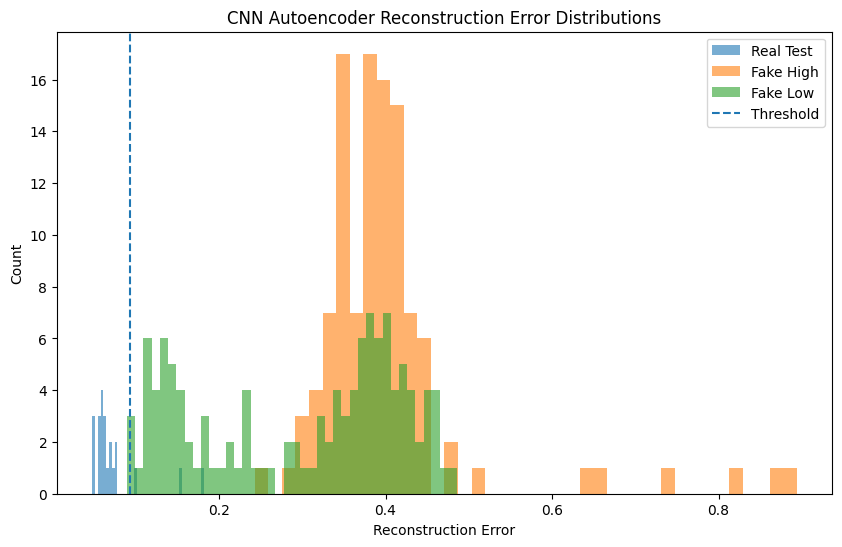

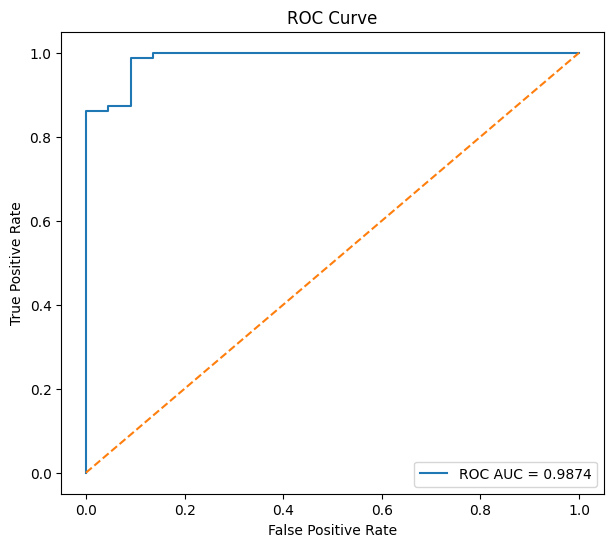

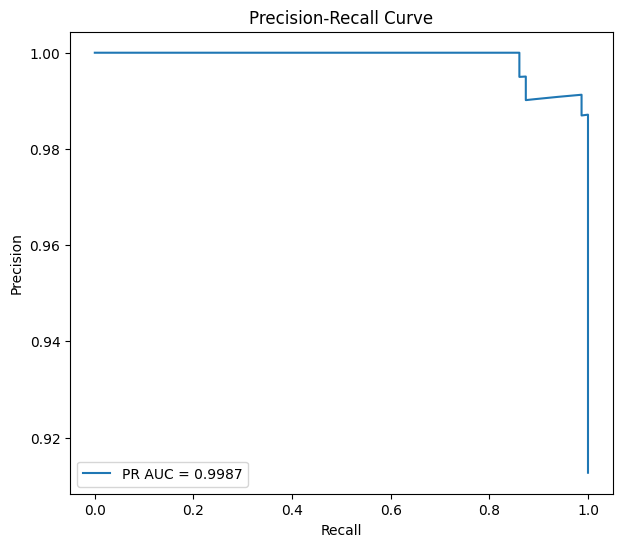

In [7]:
# ==============================
# Evaluating
# ==============================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

# ------------------------------
# Set anomaly threshold
# ------------------------------
# Since training used only Real data, choose threshold from training reconstruction errors.
# 95th percentile is a common starting point.
# Increase to 99th percentile for fewer false positives.
# ------------------------------

train_errors = reconstruction_errors(model, train_loader)

threshold = np.percentile(train_errors, 95)

print(f"Anomaly threshold: {threshold:.6f}")

# ------------------------------
# Build evaluation sets
# Label convention:
# 0 = Real
# 1 = Anomaly / Fake
# ------------------------------

y_real = np.zeros(len(real_test_errors))
y_fh = np.ones(len(fake_high_errors))
y_fl = np.ones(len(fake_low_errors))

# Combined fake high + fake low evaluation
y_true_all = np.concatenate([y_real, y_fh, y_fl])
scores_all = np.concatenate([real_test_errors, fake_high_errors, fake_low_errors])

y_pred_all = (scores_all > threshold).astype(int)

# Separate predictions
real_pred = (real_test_errors > threshold).astype(int)
fake_high_pred = (fake_high_errors > threshold).astype(int)
fake_low_pred = (fake_low_errors > threshold).astype(int)

# ------------------------------
# Summary metrics
# ------------------------------

print("\nOverall Evaluation: Real Test vs Fake High + Fake Low")
print(classification_report(
    y_true_all,
    y_pred_all,
    target_names=["Real", "Anomaly"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_true_all, y_pred_all))

roc_auc = roc_auc_score(y_true_all, scores_all)
pr_auc = average_precision_score(y_true_all, scores_all)

print(f"ROC AUC: {roc_auc:.4f}")
print(f"Average Precision / PR AUC: {pr_auc:.4f}")

# ------------------------------
# Separate detection rates
# ------------------------------

real_false_positive_rate = real_pred.mean()
fake_high_detection_rate = fake_high_pred.mean()
fake_low_detection_rate = fake_low_pred.mean()

print("\nSeparate Dataset Results")
print(f"Real test false positive rate: {real_false_positive_rate:.4f}")
print(f"Fake High detection rate:     {fake_high_detection_rate:.4f}")
print(f"Fake Low detection rate:      {fake_low_detection_rate:.4f}")

print("\nMean Reconstruction Errors")
print(f"Train Real:     {train_errors.mean():.6f}")
print(f"Test Real:      {real_test_errors.mean():.6f}")
print(f"Fake High:      {fake_high_errors.mean():.6f}")
print(f"Fake Low:       {fake_low_errors.mean():.6f}")

print("\nMedian Reconstruction Errors")
print(f"Train Real:     {np.median(train_errors):.6f}")
print(f"Test Real:      {np.median(real_test_errors):.6f}")
print(f"Fake High:      {np.median(fake_high_errors):.6f}")
print(f"Fake Low:       {np.median(fake_low_errors):.6f}")

# ------------------------------
# Plot reconstruction error distributions
# ------------------------------

plt.figure(figsize=(10, 6))
plt.hist(real_test_errors, bins=40, alpha=0.6, label="Real Test")
plt.hist(fake_high_errors, bins=40, alpha=0.6, label="Fake High")
plt.hist(fake_low_errors, bins=40, alpha=0.6, label="Fake Low")
plt.axvline(threshold, linestyle="--", label="Threshold")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("CNN Autoencoder Reconstruction Error Distributions")
plt.legend()
plt.show()

# ------------------------------
# ROC curve
# ------------------------------

fpr, tpr, _ = roc_curve(y_true_all, scores_all)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ------------------------------
# Precision-recall curve
# ------------------------------

precision, recall, _ = precision_recall_curve(y_true_all, scores_all)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()